In [1]:
import pandas as pd  # Para manejo de datos
import numpy as np   # Para operaciones numéricas
import matplotlib.pyplot as plt  # Para visualizaciones interactivas
import seaborn as sns # Para gráficos estadísticos
import missingno as msno # Para visualizar datos faltantes

## FASE 1: EXPLORACIÓN INICIAL

### Objetivo
Comprender la estructura y contenido básico de nuestro dataset antes de cualquier análisis.

### Importancia
1. Nos revela problemas de calidad de datos que deben solucionarse
2. Nos ayuda a entender qué preguntas podemos responder
3. Previene conclusiones incorrectas basadas en datos sucios

### Lo que buscaremos:
- Dimensiones del dataset (filas y columnas)
- Tipos de datos en cada columna
- Valores faltantes o extraños
- Estructura general de la información

In [2]:
# MIOOOOOO
# import kagglehub
# import os

# # Descargar el dataset del Titanic desde Kaggle
# path = kagglehub.dataset_download("fjcob1/idealista-madrid")
# print("Path to dataset files:", path)

# # Cargar el archivo Datos.csv
# df = pd.read_csv(os.path.join(path, 'Datos.csv'))

In [2]:
# Configuración para que los gráficos se vean mejor
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga dataset principal
df = pd.read_csv('./data_madrid/dataset-copy.csv', sep=',')
# Aseguramos que sea DataFrame
df = pd.DataFrame(df)
# Configurar pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# INSPECCIÓN BÁSICA

print("=== DIMENSIONES DEL DATASET ===")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\n=== PRIMERAS FILAS ===")
#display(df.head(10))
display(df.head(3))

print("\n=== INFORMACIÓN GENERAL ===")
print(df.info())

print("\n=== CONTAMOS NULOS ===")
print(df.isna().sum().sort_values(ascending=False))

print("\n=== ESTADÍSTICAS BÁSICAS ===")
print(df.describe())

print("\n=== ESTADÍSTICAS PARA COLUMNAS CATEGORICAS ===")
#print(df.select_dtypes(include='str').describe())
print(df.select_dtypes(include='object').describe())

print("\n=== VALORES ÚNICOS POR COLUMNA ===")
print(df.columns.tolist())

# value_counts() nos dice cuántas veces aparece cada valor en una columna
print("=== ASCENSOR ===")
print(df['ascensor'].value_counts(dropna=False))


print("\n=== LOCALIZACIÓN ===")
print(df['localizacion'].value_counts(dropna=False))


print("\n=== PLANTA (top 10) ===")
print(df['planta'].value_counts(dropna=False).head(10))

print("\n=== ZONA ===")
print(df['zona'].value_counts())



=== DIMENSIONES DEL DATASET ===
Filas: 11826
Columnas: 14

=== PRIMERAS FILAS ===


,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,1.0,S,NaN,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/



=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 11826 entries, 0 to 11825
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   provincia       11826 non-null  str    
 1   zona            11826 non-null  str    
 2   titulo          11826 non-null  str    
 3   PrecioActual    11826 non-null  int64  
 4   PrecioAnterior  11826 non-null  int64  
 5   metros          11826 non-null  int64  
 6   habitaciones    11460 non-null  float64
 7   ascensor        11033 non-null  str    
 8   localizacion    10730 non-null  str    
 9   planta          10601 non-null  str    
 10  baños           11826 non-null  int64  
 11  tags            11664 non-null  str    
 12  descripcion     11761 non-null  str    
 13  Enlace          11826 non-null  str    
dtypes: float64(1), int64(4), str(9)
memory usage: 1.3 MB
None

=== CONTAMOS NULOS ===
planta            1225
localizacion      1096
ascensor           7

C:\Users\user\AppData\Local\Temp\ipykernel_2812\3039950893.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').describe())


### Identificar columnas a descartar
Hay columnas que no aportan información para el modelo. Descartarlas antes simplifica todo el análisis:

In [3]:
columnas_a_descartar = [
    'provincia',
    'Enlace',
    'descripcion',
    'titulo',
]

### Investigar los ceros sospechosos
¿Cuántos hay en columnas donde 0 no tiene sentido?

In [4]:
print("=== CEROS SOSPECHOSOS ===")
print(f"baños = 0: {(df['baños'] == 0).sum()} de {len(df)} ({(df['baños'] == 0).mean()*100:.1f}%)")

=== CEROS SOSPECHOSOS ===
baños = 0: 9311 de 11826 (78.7%)


**Interpretación**:
- `baños`: 78.7% con valor 0 → casi seguro que son "no reportado", no pisos sin baño

## Sección 2: Análisis de la variable objetivo (PrecioActual)

La **variable objetivo** (también llamada **target** o **variable dependiente**) es lo que queremos predecir. En nuestro caso: `PrecioActual`.

Antes de construir un modelo, necesitamos entender cómo se comporta esta variable.

In [5]:
print("=== VARIABLE OBJETIVO: PrecioActual ===")
print(df['PrecioActual'].describe())
print(f"\nMediana:  {df['PrecioActual'].median():,.0f} €")
print(f"Media:    {df['PrecioActual'].mean():,.0f} €")
print(f"Mínimo:   {df['PrecioActual'].min():,.0f} €")
print(f"Máximo:   {df['PrecioActual'].max():,.0f} €")

=== VARIABLE OBJETIVO: PrecioActual ===
count    1.182600e+04
mean     1.030501e+06
std      1.237718e+06
min      1.200000e+04
25%      2.890000e+05
50%      6.200000e+05
75%      1.329000e+06
max      2.300000e+07
Name: PrecioActual, dtype: float64

Mediana:  620,000 €
Media:    1,030,501 €
Mínimo:   12,000 €
Máximo:   23,000,000 €


**Interpretación**: La media es mucho mayor que la mediana. Esto nos dice que hay unos pocos pisos MUY caros que "estiran" la media hacia arriba. Esto se llama **distribución sesgada a la derecha** (right-skewed).
### Distribución visual:

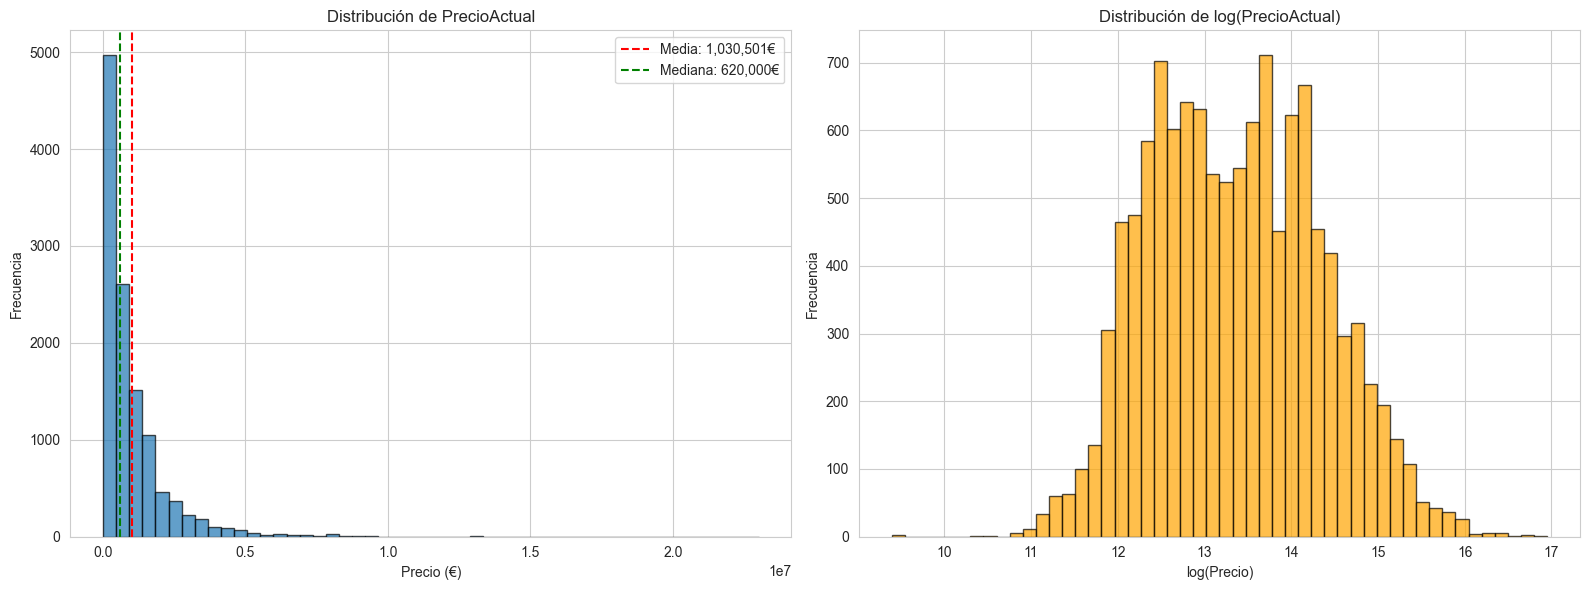

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma del precio original
axes[0].hist(df['PrecioActual'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de PrecioActual')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')
# Añadir líneas de media y mediana para ver la diferencia
axes[0].axvline(df['PrecioActual'].mean(), color='red', linestyle='--', label=f"Media: {df['PrecioActual'].mean():,.0f}€")
axes[0].axvline(df['PrecioActual'].median(), color='green', linestyle='--', label=f"Mediana: {df['PrecioActual'].median():,.0f}€")
axes[0].legend()

# Histograma del log del precio
# np.log1p = log(x + 1), se usa en vez de np.log para evitar log(0) ! 
axes[1].hist(np.log1p(df['PrecioActual']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Distribución de log(PrecioActual)')
axes[1].set_xlabel('log(Precio)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## FASE 2: LIMPIEZA Y PREPARACIÓN

### Objetivo
Transformar nuestros datos crudos en un dataset limpio y analizable.

### Principios de Limpieza:
1. **Nunca modificamos el original** - Siempre trabajamos con una copia
2. **Documentamos cada cambio** - Para que otros puedan entender el proceso
3. **Validamos cada paso** - Nos aseguramos que la limpieza funcionó


              nulos  porcentaje
planta         1225       10.36
localizacion   1096        9.27
ascensor        793        6.71
habitaciones    366        3.09
tags            162        1.37
descripcion      65        0.55


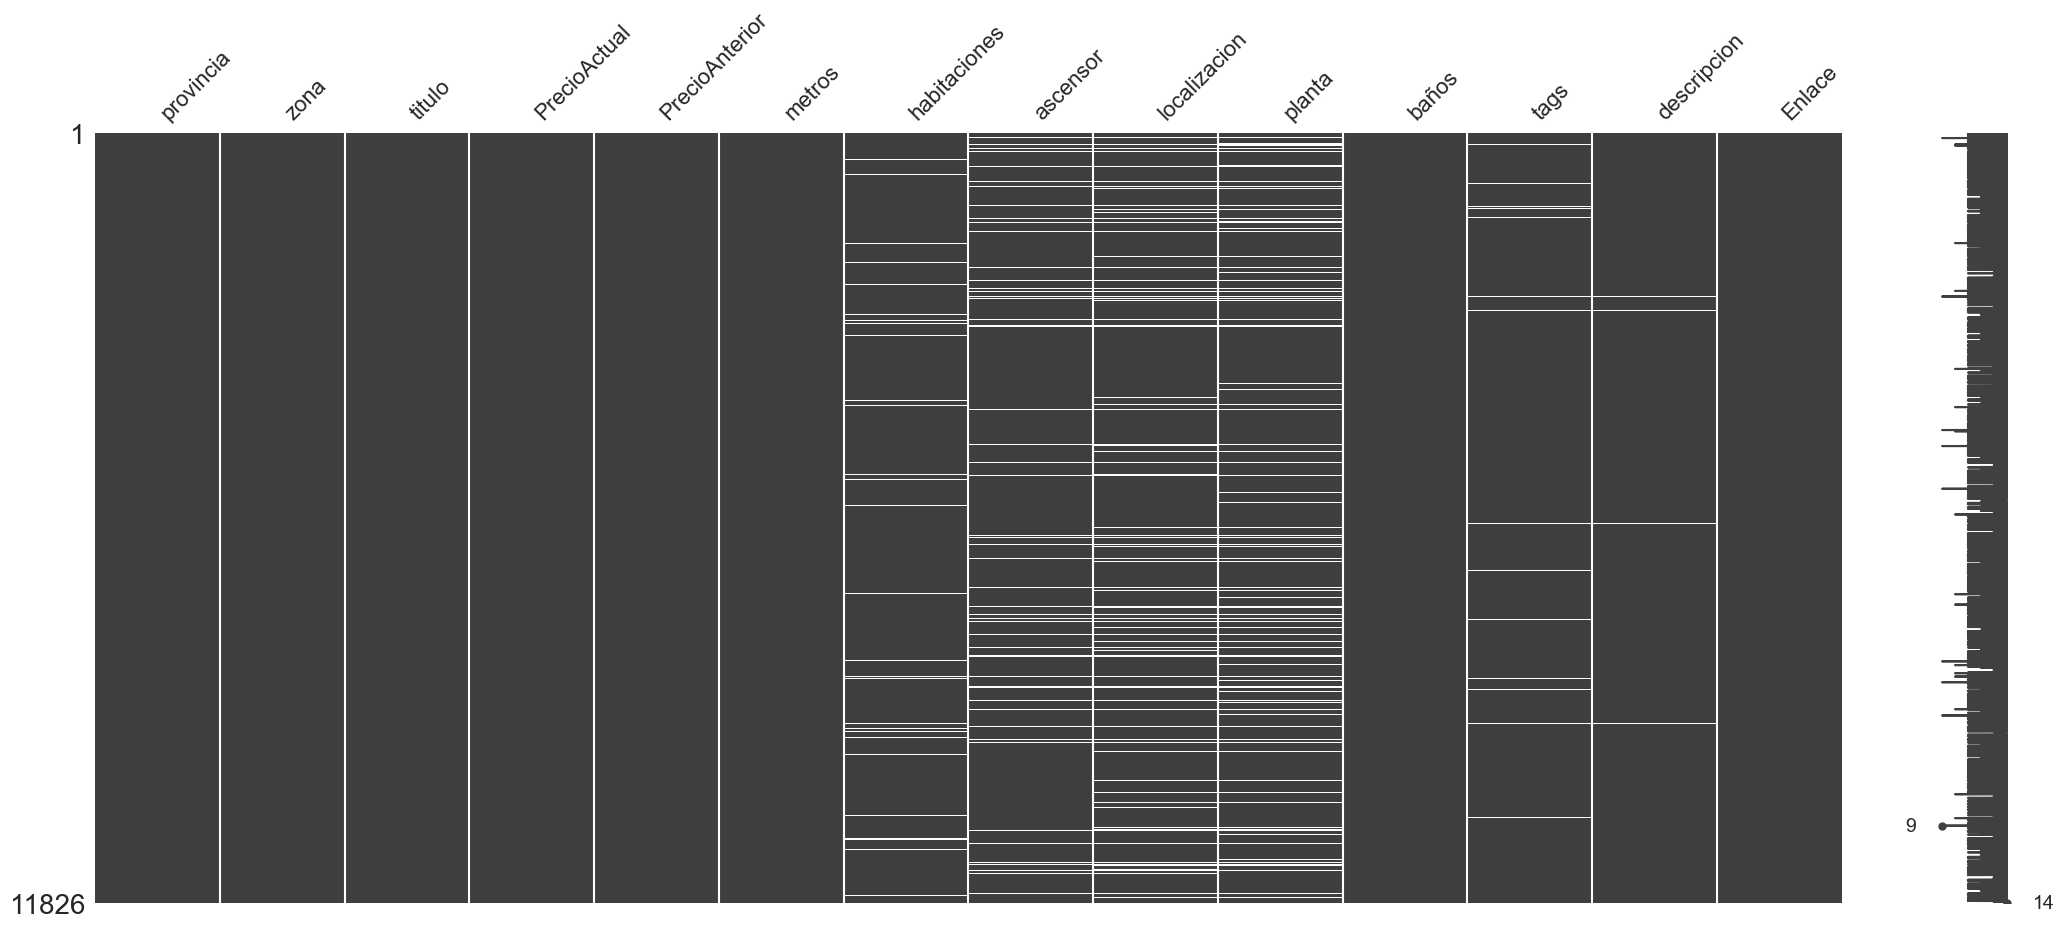

In [7]:

# Calcular nulos en números absolutos y en porcentaje
nulos = pd.DataFrame({
    'nulos': df.isnull().sum(),
    'porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
})
# Filtrar solo columnas con nulos y ordenar de mayor a menor
nulos = nulos[nulos['nulos'] > 0].sort_values('porcentaje', ascending=False)
print(nulos)

# MAtriz que permite ver de un vistazo DÓNDE están los huecos y si hay patrones
msno.matrix(df)
plt.show()

### 3.3 Analizar patrones: ¿POR QUÉ faltan datos?

No todos los nulos son iguales. Hay tres tipos:

1. **MCAR** (Missing Completely At Random): Faltan por azar puro, sin relación con nada
2. **MAR** (Missing At Random): Faltan por razones relacionadas con OTRAS columnas
3. **MNAR** (Missing Not At Random): Faltan por razones relacionadas con la PROPIA columna

En nuestro dataset, sospechamos que hay un patrón: los **chalets** probablemente no tienen `planta`, `ascensor` porque esos conceptos no aplican a chalets.
Si vemos que la mayoría de los NaN en `planta` y `ascensor` son chalets o casas, la estrategia de imputación será diferente: no les asignamos la mediana, sino un valor especial que refleje "no aplica".

In [9]:
# Comprobemos: ¿los registros con planta=NaN son más frecuentemente chalets?
# Primero extraemos el tipo de inmueble del título
df['tipo_inmueble'] = df['titulo'].str.extract(r'^(\w+)', expand=False)

# Ahora cruzamos: de los registros sin planta, ¿cuántos son de cada tipo?
print("=== TIPO DE INMUEBLE donde planta es NaN ===")
sin_planta = df[df['planta'].isna()]
print(sin_planta['tipo_inmueble'].value_counts())
print(f"\nTotal sin planta: {len(sin_planta)}")

print("\n=== TIPO DE INMUEBLE donde ascensor es NaN ===")
sin_ascensor = df[df['ascensor'].isna()]
print(sin_ascensor['tipo_inmueble'].value_counts())
print(f"\nTotal sin ascensor: {len(sin_ascensor)}")

# ¿Los pisos sin dato de ascensor se parecen más a los de S o a los de N?
pisos = df[df['titulo'].str.startswith('Piso')]
for grupo in ['S', 'N']:
    subset = pisos[pisos['ascensor'] == grupo]
    print(f"ascensor={grupo}: precio medio={subset['PrecioActual'].mean():,.0f}€, metros={subset['metros'].mean():.0f}")

subset_nan = pisos[pisos['ascensor'].isna()]
print(f"ascensor=NaN: precio medio={subset_nan['PrecioActual'].mean():,.0f}€, metros={subset_nan['metros'].mean():.0f}")

# ¿Quiénes son los NaN de localizacion?
print("\n=== TIPO DE INMUEBLE donde localizacion es NaN ===")
sin_loc = df[df['localizacion'].isna()]
print(sin_loc['tipo_inmueble'].value_counts())
print(f"\nTotal sin localización: {len(sin_loc)}")

# Todo lo que NO sea Chalet ni Casa  
print("\n=== Precio medio segun localizacion (Sin casas ni chalets) ===")                                         
inmuebles = df[~df['tipo_inmueble'].isin(['Chalet', 'Casa'])]
for grupo in ['EXTERIOR', 'INTERIOR']:
    subset = inmuebles[inmuebles['localizacion'] == grupo]
    print(f"loc={grupo}: precio medio={subset['PrecioActual'].mean():,.0f}€,metros={subset['metros'].mean():.0f}")

subset_nan = inmuebles[inmuebles['localizacion'].isna()]
print(f"loc=NaN:      precio medio={subset_nan['PrecioActual'].mean():,.0f}€,metros={subset_nan['metros'].mean():.0f}")
print(f"Total NaN (sin chalets/casas): {len(subset_nan)}")


=== TIPO DE INMUEBLE donde planta es NaN ===
tipo_inmueble
Piso       446
Chalet     398
Casa       321
Ático       43
Estudio      9
Dúplex       8
Name: count, dtype: int64

Total sin planta: 1225

=== TIPO DE INMUEBLE donde ascensor es NaN ===
tipo_inmueble
Chalet     398
Casa       321
Piso        55
Estudio     19
Name: count, dtype: int64

Total sin ascensor: 793
ascensor=S: precio medio=1,144,021€, metros=139
ascensor=N: precio medio=335,861€, metros=107
ascensor=NaN: precio medio=281,172€, metros=75

=== TIPO DE INMUEBLE donde localizacion es NaN ===
tipo_inmueble
Chalet     398
Piso       350
Casa       321
Estudio     24
Dúplex       2
Ático        1
Name: count, dtype: int64

Total sin localización: 1096

=== Precio medio segun localizacion (Sin casas ni chalets) ===
loc=EXTERIOR: precio medio=1,047,347€,metros=142
loc=INTERIOR: precio medio=587,945€,metros=77
loc=NaN:      precio medio=286,764€,metros=81
Total NaN (sin chalets/casas): 377


### Análisis del caso especial: baños con valor 0
Si los pisos con baños=0 tienen metros, habitaciones y precios similares a los de baños>0, eso confirma que el 0 significa "no reportado" y no "sin baño".

In [10]:
# Cruzar baños=0 con otras variables para entender el patrón
print("=== PISOS CON baños=0 vs baños>0 ===")
print(f"Media de metros  (baños=0): {df[df['baños']==0]['metros'].mean():.0f}")
print(f"Media de metros  (baños>0): {df[df['baños']>0]['metros'].mean():.0f}")
print(f"Media de precio  (baños=0): {df[df['baños']==0]['PrecioActual'].mean():,.0f}€")
print(f"Media de precio  (baños>0): {df[df['baños']>0]['PrecioActual'].mean():,.0f}€")
print(f"Media de habitac (baños=0): {df[df['baños']==0]['habitaciones'].mean():.1f}")
print(f"Media de habitac (baños>0): {df[df['baños']>0]['habitaciones'].mean():.1f}")

=== PISOS CON baños=0 vs baños>0 ===
Media de metros  (baños=0): 160
Media de metros  (baños>0): 130
Media de precio  (baños=0): 1,060,193€
Media de precio  (baños>0): 920,577€
Media de habitac (baños=0): 2.9
Media de habitac (baños>0): 2.8


## Estrategia de tratamiento de nulos para baños

### El problema de dejar los 0s como están

Si dejamos `baños = 0`, pandas y cualquier modelo lo tratan como un dato real:
**"este piso tiene cero baños"**. Todas las operaciones lo usan:

- `.mean()` se calcula incluyendo esos 0s → la media baja artificialmente
- `.corr()` calcula correlaciones con 0s falsos → relaciones distorsionadas
- Un modelo de regresión aprende que "0 baños" es una característica real → predicciones malas

**NaN** en cambio significa **"no lo sé"**. Y pandas por defecto ignora los NaN en cálculos. Así las estadísticas, gráficos y correlaciones se hacen solo con datos reales (1, 2, 3... baños).

### ¿Y por qué no meter la mediana directamente?

Podrías, pero hay un tema de escala: el **78.7%** del dataset no tiene este dato. Eso es casi **4 de cada 5 pisos**.

Si metes la mediana a ese 78.7%, le estás diciendo al modelo _"estoy segura de que estos 9,311 pisos tienen X baños"_. Y no es verdad — **no lo sabes**. Estás inventando datos para la inmensa mayoría de tus registros.

Con ese nivel de datos faltantes, las opciones reales son:

| Opción | Cuándo tiene sentido |
|--------|---------------------|
| **Imputar con mediana** (global o por zona) | Si faltan pocos datos (~5-10%) |
| **Eliminar la columna entera** | Si falta demasiado (~70%+) y la columna no es crítica |
| **Dejar NaN y usar modelos que los toleran** | Si usas Random Forest o XGBoost, que saben trabajar con NaN |

### Conclusión

Con un **78.7% de datos faltantes**, eliminar la columna `baños` probablemente sea la decisión más honesta. Inventar datos para 4 de cada 5 registros introduce más ruido del que la columna aporta.

Convertir a NaN primero da la libertad de tomar esa decisión después, con toda la información.

In [11]:
# --- copia del dataset ---
df_clean = df.copy()

In [12]:
# --- baños: convertir 0s a NaN ---
#EJECUTAR SOLO SI QUIERES DATOS DE BAÑO 0 PASE A NULO
# df_clean['baños'] = df_clean['baños'].replace(0, np.nan)
# print(f"baños: convertidos {(df['baños']==0).sum()} ceros a NaN")

# print(df_clean['baños'].unique())

In [13]:
# --- baños: convertir 0s a 1 o más ---

# Regla: 3+ habitaciones → 2 baños, resto → 1 baño
# df_clean.loc[(df_clean['baños'] == 0) & (df_clean['habitaciones'] >= 3), 'baños'] = 2                                                     

# df_clean.loc[df_clean['baños'] == 0,'baños'] = 1
# print(df_clean['baños'].unique())

### Estrategia para Ascensores
ascensor=S: precio medio=1,144,021€, metros=139
ascensor=N: precio medio=335,861€, metros=107
ascensor=NaN: precio medio=281,172€, metros=75
Mas arriba confirmamos que las caracteristicas de PISOS con ascensor NaN se acercan mas a la media de pisos sin ascensor

In [12]:
# --- Chalets y Casas → NO_APLICA
df_clean.loc[
      (df_clean['ascensor'].isna()) &
      (df_clean['tipo_inmueble'].isin(['Chalet', 'Casa'])),
      'ascensor'] = 'NO_APLICA'

# 2. Pisos → "N" (confirmado con datos)
df_clean.loc[(df_clean['ascensor'].isna()) &(df_clean['tipo_inmueble'] == 'Piso'),'ascensor'] = 'N'

# 3. Resto (Atico, Dúplex, Estudio) → moda por tipo
df_clean['ascensor'] = df_clean.groupby('tipo_inmueble')['ascensor'].transform(
      lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'S')
  )


### Estrategia para Localizacion
loc=EXTERIOR: precio medio=1,047,347€,metros=142
loc=NaN:      precio medio=286,764€,metros=81

loc=INTERIOR: precio medio=587,945€,metros=77
loc=NaN:      precio medio=286,764€,metros=81

**Total NaN**(sin chalets/casas): **377**
A pesar de que el precio medio dista respecto al precio medio de los que si estan categorizados con localizacion, el dato de NaN es minimo respecto al dataset completo y rellenamos con la moda todos los inmuebles que no sean casa o chalet donde no aplica

In [13]:
# 1. Chalets y Casas → NO_APLICA
df_clean.loc[
      (df_clean['localizacion'].isna()) &
      (df_clean['tipo_inmueble'].isin(['Chalet', 'Casa'])),
      'localizacion'
  ] = 'NO_APLICA'

# 2. Resto → moda por tipo de inmueble
df_clean['localizacion'] = df_clean.groupby('tipo_inmueble')['localizacion'].transform(
      lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else 'EXTERIOR')
  )


### Estrategia para plantas

In [14]:
# ---  categoría especial para chalets/casas ---
df_clean.loc[
    (df_clean['planta'].isna()) & (df_clean['tipo_inmueble'].isin(['Chalet', 'Casa'])),
    'planta'
] = 'NO_APLICA'

# Para el resto de inmuebles con NaN en planta, usar la moda  por tipo de inmueble
df_clean['planta'] = df_clean.groupby('tipo_inmueble')['planta'].transform(
      lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else '1ª')
  )

df_clean['plantaN'] = df_clean['planta'].str.split('ª', n=1).str[0]
df_clean['plantaN'] = df_clean['plantaN'].replace('BAJO', '0')
df_clean['plantaN'] = df_clean['plantaN'].replace('ENTREPLANTA', '0.5')
df_clean['plantaN'] = df_clean['plantaN'].replace('SÓTANO', '-1')


print(df_clean['plantaN'].unique())


['5' '1' '2' '0' '3' '6' 'NO_APLICA' '4' '16' '13' '9' '7' '10' '8' '14'
 '11' '12' '0.5' '-1' '15' '17' '20' '-2' '27' '22' '21' '18']


In [15]:
display(df_clean.head(5))

,provincia,zona,titulo,PrecioActual,PrecioAnterior,metros,habitaciones,ascensor,localizacion,planta,baños,tags,descripcion,Enlace,tipo_inmueble,plantaN
0,madrid,ciudad-lineal,"Piso en calle de San Marcelo, 22, Ventas, Madrid",355000,0,69,2.0,S,EXTERIOR,5ª,1,"VIVIENDA,LUMINOSO,VISTAS,REFORMADA,PORTERO,EXT...",Particular Vende vivienda totalmente reformada...,https://www.idealista.com/inmueble/106956987/,Piso,5
1,madrid,carabanchel,"Piso en calle Cabo Nicolás Mur, San Isidro, Ma...",149000,159000,91,3.0,N,EXTERIOR,1ª,0,"PISO,EXCLUSIVA,INMOBILIARIA,OPORTUNIDAD",Inmobiliarias Encuentro vende en exclusiva la ...,https://www.idealista.com/inmueble/106906044/,Piso,1
2,madrid,centro,"Piso en calle de Rodas, Lavapiés-Embajadores, ...",195000,0,36,1.0,S,EXTERIOR,2ª,0,"EXCLUSIVA,ESTUDIO",ESTUDIO EN PLENO CENTRO DE MADRIDSarago Servic...,https://www.idealista.com/inmueble/107306175/,Piso,2
3,madrid,usera,"Piso en calle de Ferroviarios, Almendrales, Ma...",195000,0,58,1.0,S,INTERIOR,BAJO,0,"VIVIENDA,HOGAR,FUNCIONAL","Esta acogedora vivienda, ubicada en una planta...",https://www.idealista.com/inmueble/106325171/,Piso,0
4,madrid,tetuan,"Dúplex en Bellas Vistas, Madrid",715000,750000,140,3.0,S,EXTERIOR,2ª,0,"TERRAZA,EXCLUSIVA,MODERNO","Maravilloso ATICO de reciente construcción, co...",https://www.idealista.com/inmueble/106627265/,Dúplex,2


# CAMBIOS JUANMA
### Borrar columnas innecesarias

In [16]:
df_juanma_copia = df_clean.copy()

In [17]:
df_clean = df_clean.drop(['provincia', 'titulo', 'PrecioAnterior', 'planta', 'baños', 'tags', 'descripcion', 'Enlace'], axis=1)

In [18]:
df_clean.head(5)

,zona,PrecioActual,metros,habitaciones,ascensor,localizacion,tipo_inmueble,plantaN
0,ciudad-lineal,355000,69,2.0,S,EXTERIOR,Piso,5
1,carabanchel,149000,91,3.0,N,EXTERIOR,Piso,1
2,centro,195000,36,1.0,S,EXTERIOR,Piso,2
3,usera,195000,58,1.0,S,INTERIOR,Piso,0
4,tetuan,715000,140,3.0,S,EXTERIOR,Dúplex,2


### Numerar zonas en columna nueva zona_id

In [36]:
df_clean['zona_id'] = df_clean['zona'].astype('category').cat.codes

df_clean['zona_id'] = df_clean['zona_id'] + 1

display(df_clean[['zona', 'zona_id']].drop_duplicates().head(10))

with pd.option_context('display.max_rows', None):
    display(df_clean[['zona_id', 'zona']].drop_duplicates().sort_values('zona_id'))

,zona,zona_id
0,ciudad-lineal,8
1,carabanchel,4
2,centro,5
3,usera,18
4,tetuan,17
5,arganzuela,1
6,barrio-de-salamanca,3
7,puente-de-vallecas,14
8,moncloa,12
9,chamberi,7


,zona_id,zona
5,1,arganzuela
73,2,barajas
6,3,barrio-de-salamanca
1,4,carabanchel
2,5,centro
11,6,chamartin
9,7,chamberi
0,8,ciudad-lineal
18,9,fuencarral
36,10,hortaleza


In [37]:
# guardar dataframe con zonas y su id
df_zonas = df_clean[['zona_id', 'zona']].drop_duplicates().sort_values('zona_id')
df_zonas

,zona_id,zona
5,1,arganzuela
73,2,barajas
6,3,barrio-de-salamanca
1,4,carabanchel
2,5,centro
11,6,chamartin
9,7,chamberi
0,8,ciudad-lineal
18,9,fuencarral
36,10,hortaleza


### Columna ascensor poner a 1 o 0

In [21]:
valores_unicos = df_clean['ascensor'].unique()
print(valores_unicos)

<StringArray>
['S', 'N', 'NO_APLICA']
Length: 3, dtype: str


In [22]:
valores_unicos = df_clean['ascensor'].value_counts()
print(valores_unicos)

ascensor
S            8438
N            2669
NO_APLICA     719
Name: count, dtype: int64


In [23]:
# Poner los siguientes valores según ascensor : S = 1 - N = 0 - NO_APLICA = 0
df_clean['ascensor'] = df_clean['ascensor'].replace('S', '1')
df_clean['ascensor'] = df_clean['ascensor'].replace('N', '0')
df_clean['ascensor'] = df_clean['ascensor'].replace('NO_APLICA', '0')

In [24]:
valores_unicos = df_clean['ascensor'].value_counts()
print(valores_unicos)

ascensor
1    8438
0    3388
Name: count, dtype: int64


In [25]:
# Convertir la columna ascensor a int
df_clean['ascensor'] = df_clean['ascensor'].astype(int)

### Columna localizacion poner a 1 o 0

In [26]:
valores_unicos = df_clean['localizacion'].unique()
print(valores_unicos)

<StringArray>
['EXTERIOR', 'INTERIOR', 'NO_APLICA']
Length: 3, dtype: str


In [27]:
valores_unicos = df_clean['localizacion'].value_counts()
print(valores_unicos)

localizacion
EXTERIOR     9464
INTERIOR     1643
NO_APLICA     719
Name: count, dtype: int64


In [28]:
# Poner los siguientes valores según localizacion : EXTERIOR = 1 - INTERIOR = 0 - NO_APLICA = 1
df_clean['localizacion'] = df_clean['localizacion'].replace('EXTERIOR', '1')
df_clean['localizacion'] = df_clean['localizacion'].replace('INTERIOR', '0')
df_clean['localizacion'] = df_clean['localizacion'].replace('NO_APLICA', '1')

In [29]:
valores_unicos = df_clean['localizacion'].value_counts()
print(valores_unicos)

localizacion
1    10183
0     1643
Name: count, dtype: int64


In [30]:
# Convertir la columna localizacion a int
df_clean['localizacion'] = df_clean['localizacion'].astype(int)

### Columna plantaN poner NO_APLICA a 0

In [31]:
# Poner los siguientes valores según localizacion : NO_APLICA = 0
df_clean['plantaN'] = df_clean['plantaN'].replace('NO_APLICA', '0')

In [32]:
# Convertir la columna plantaN a float
df_clean['plantaN'] = df_clean['plantaN'].astype(float)

### Numerar tipo_inmueble en columna nueva tipo_inmueble_id

In [38]:
df_clean['tipo_inmueble_id'] = df_clean['tipo_inmueble'].astype('category').cat.codes

df_clean['tipo_inmueble_id'] = df_clean['tipo_inmueble_id'] + 1

display(df_clean[['tipo_inmueble', 'tipo_inmueble_id']].drop_duplicates().head(10))

with pd.option_context('display.max_rows', None):
    display(df_clean[['tipo_inmueble_id', 'tipo_inmueble']].drop_duplicates().sort_values('tipo_inmueble_id'))

,tipo_inmueble,tipo_inmueble_id
0,Piso,5
4,Dúplex,3
8,Chalet,2
24,Ático,6
42,Estudio,4
47,Casa,1


,tipo_inmueble_id,tipo_inmueble
47,1,Casa
8,2,Chalet
4,3,Dúplex
42,4,Estudio
0,5,Piso
24,6,Ático


In [39]:
# guardar dataframe con zonas y su id
df_tipo_inmuebles = df_clean[['tipo_inmueble_id', 'tipo_inmueble']].drop_duplicates().sort_values('tipo_inmueble_id')
df_tipo_inmuebles

,tipo_inmueble_id,tipo_inmueble
47,1,Casa
8,2,Chalet
4,3,Dúplex
42,4,Estudio
0,5,Piso
24,6,Ático


In [40]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 11826 entries, 0 to 11825
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   zona              11826 non-null  str    
 1   PrecioActual      11826 non-null  int64  
 2   metros            11826 non-null  int64  
 3   habitaciones      11460 non-null  float64
 4   ascensor          11826 non-null  int64  
 5   localizacion      11826 non-null  int64  
 6   tipo_inmueble     11826 non-null  str    
 7   plantaN           11826 non-null  float64
 8   zona_id           11826 non-null  int8   
 9   tipo_inmueble_id  11826 non-null  int8   
dtypes: float64(2), int64(4), int8(2), str(2)
memory usage: 762.4 KB


# Analisis Univariado

## Variable numérica habitaciones

### Borrar las filas con habitaciones > 8 por considerarlos outliers

In [41]:
df_clean = df_clean[df_clean['habitaciones'] <= 8]
cuantos = df_clean[df_clean['habitaciones'] > 8]['habitaciones'].count()
print(cuantos)

0


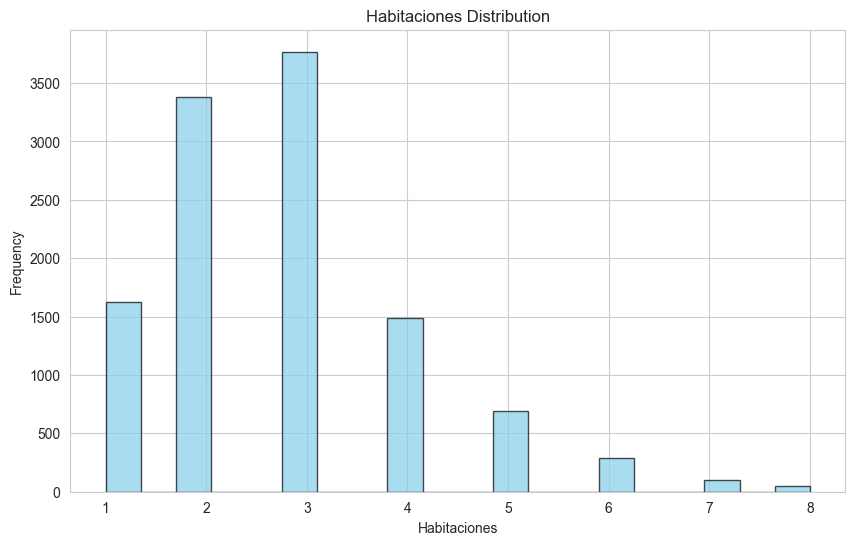

In [42]:
# Histograma para ver la distribución de habitaciones
# bins=20 divide las habitaciones en 20 rangos
# edgecolor='black' añade un borde negro a cada barra para distinguirlas mejor
# alpha=0.7 hace las barras ligeramente transparentes
df_clean['habitaciones'].plot(kind='hist', bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Habitaciones Distribution')
plt.xlabel('Habitaciones')
plt.ylabel('Frequency')
plt.show()

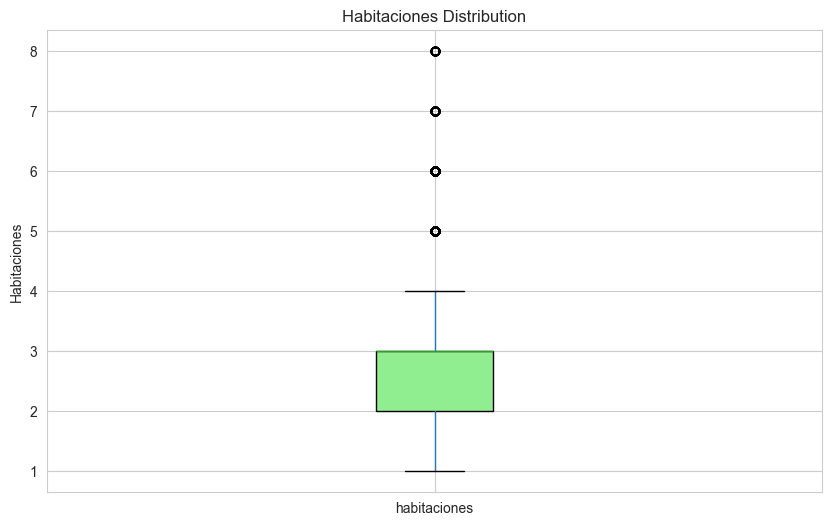

In [43]:
# Boxplot para detectar valores extremos (outliers)
# Un boxplot muestra la distribución de los datos y resalta valores anómalos
df_clean.boxplot(column='habitaciones', patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))
plt.title('Habitaciones Distribution')  # Distribución del precio de los tickets
plt.ylabel('Habitaciones')
plt.show()

### Variable numérica de metros

### Borrar las filas con metros > 600 por considerarlos outliers

In [44]:
df_clean = df_clean[df_clean['metros'] <= 600]
cuantos = df_clean[df_clean['metros'] > 600]['metros'].count()
print(cuantos)

0


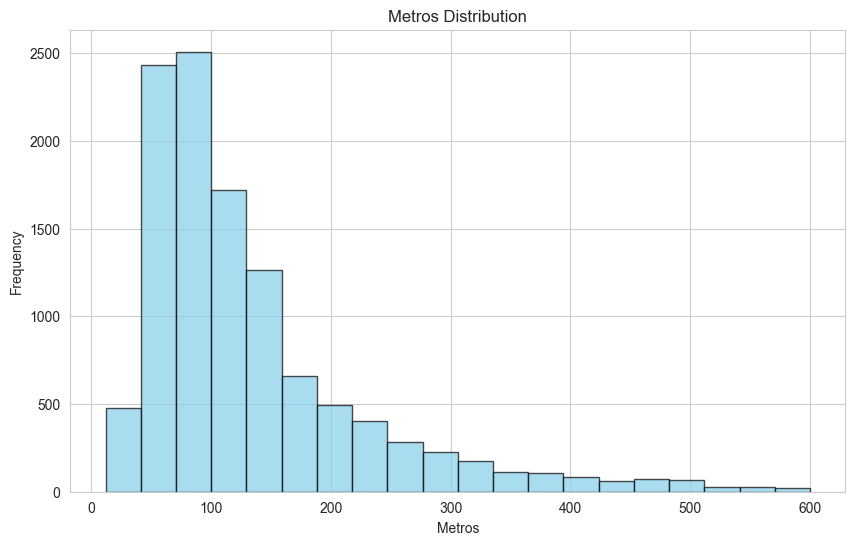

In [45]:
df_clean['metros'].plot(kind='hist', bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Metros Distribution')
plt.xlabel('Metros')
plt.ylabel('Frequency')
plt.show()

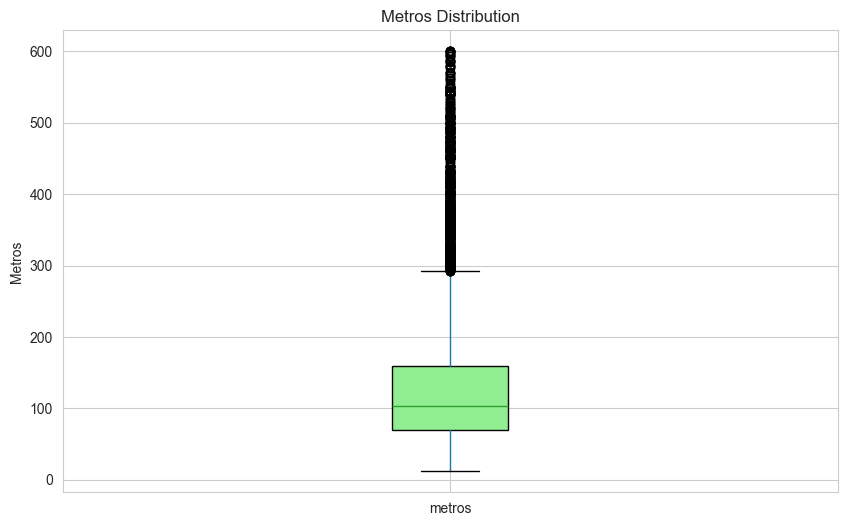

In [46]:
df_clean.boxplot(column='metros', patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))
plt.title('Metros Distribution')  # Distribución del precio de los tickets
plt.ylabel('Metros')
plt.show()

### Variable numérica de PrecioActual

### Borrar las filas con PrecioActual > 6.000.000 por considerarlos outliers

In [47]:
df_clean = df_clean[df_clean['PrecioActual'] <= 6000000]
cuantos = df_clean[df_clean['PrecioActual'] > 6000000]['PrecioActual'].count()
print(cuantos)

0


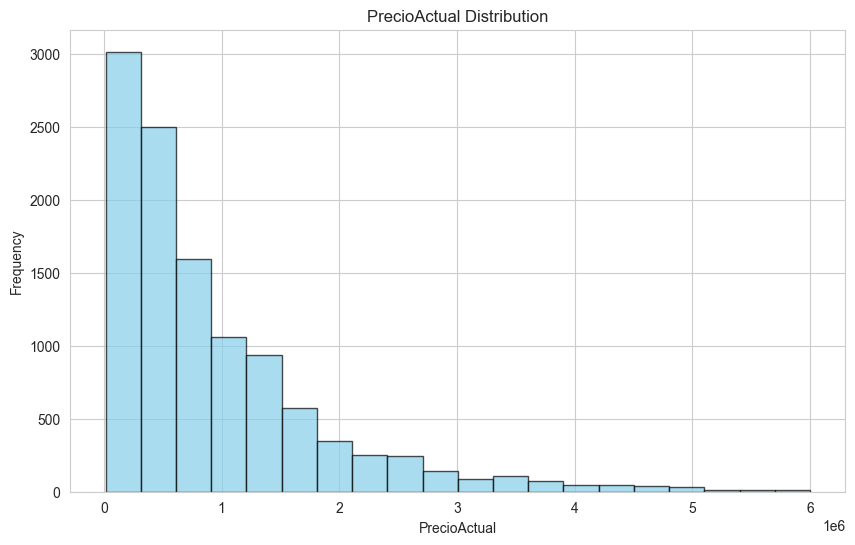

In [48]:
df_clean['PrecioActual'].plot(kind='hist', bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('PrecioActual Distribution')
plt.xlabel('PrecioActual')
plt.ylabel('Frequency')
plt.show()

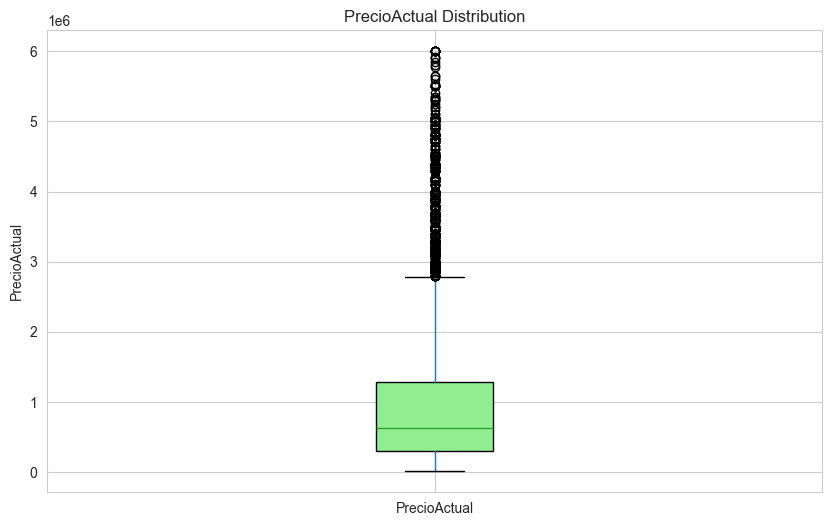

In [49]:
df_clean.boxplot(column='PrecioActual', patch_artist=True,
           boxprops=dict(facecolor='lightgreen'))
plt.title('PrecioActual Distribution')  # Distribución del precio de los tickets
plt.ylabel('PrecioActual')
plt.show()

### Matriz de correlación

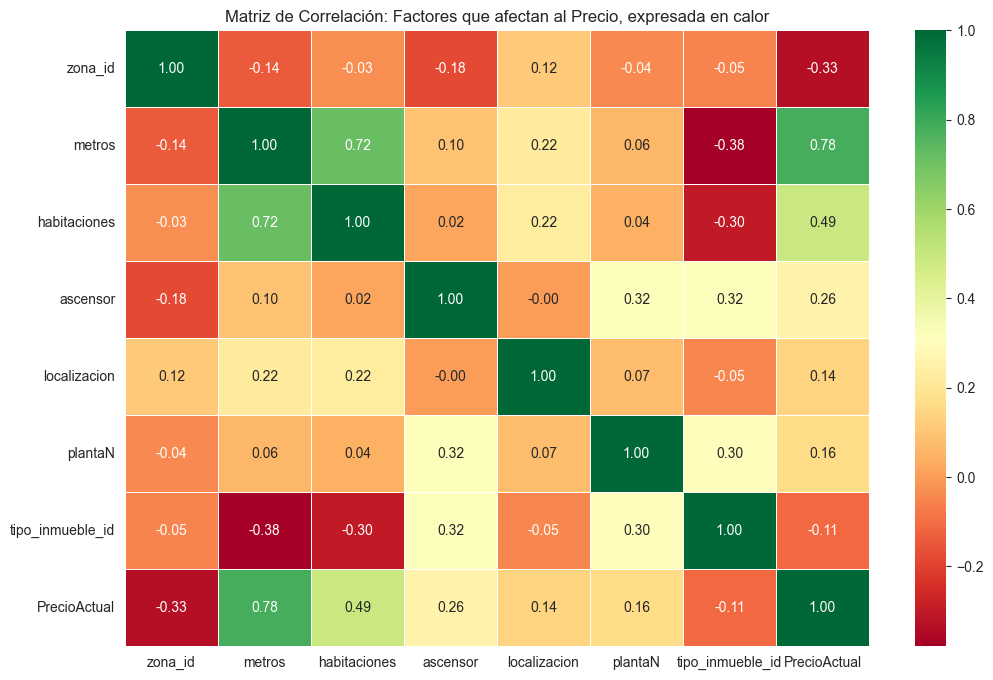

In [50]:
#import seaborn as sns
#import matplotlib.pyplot as plt

cols_para_corr = ['zona_id', 'metros', 'habitaciones', 'ascensor', 'localizacion', 'plantaN', 'tipo_inmueble_id', 'PrecioActual']
matriz = df_clean[cols_para_corr].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title("Matriz de Correlación: Factores que afectan al Precio, expresada en calor")
plt.show()

### Borrar columnas zona y tipo_inmueble

In [51]:
df_clean.drop(['zona', 'tipo_inmueble'], axis=1, inplace=True)

In [52]:
df_clean.head(5)

,PrecioActual,metros,habitaciones,ascensor,localizacion,plantaN,zona_id,tipo_inmueble_id
0,355000,69,2.0,1,1,5.0,8,5
1,149000,91,3.0,0,1,1.0,4,5
2,195000,36,1.0,1,1,2.0,5,5
3,195000,58,1.0,1,0,0.0,18,5
4,715000,140,3.0,1,1,2.0,17,3


In [53]:
df_zonas

,zona_id,zona
5,1,arganzuela
73,2,barajas
6,3,barrio-de-salamanca
1,4,carabanchel
2,5,centro
11,6,chamartin
9,7,chamberi
0,8,ciudad-lineal
18,9,fuencarral
36,10,hortaleza


In [54]:
df_tipo_inmuebles

,tipo_inmueble_id,tipo_inmueble
47,1,Casa
8,2,Chalet
4,3,Dúplex
42,4,Estudio
0,5,Piso
24,6,Ático


### Exportar a un fichero csv con los datos limpios

In [55]:
df_clean.to_csv('data_madrid/datClean.csv', index=False)

In [56]:
df_clean.head()

,PrecioActual,metros,habitaciones,ascensor,localizacion,plantaN,zona_id,tipo_inmueble_id
0,355000,69,2.0,1,1,5.0,8,5
1,149000,91,3.0,0,1,1.0,4,5
2,195000,36,1.0,1,1,2.0,5,5
3,195000,58,1.0,1,0,0.0,18,5
4,715000,140,3.0,1,1,2.0,17,3


In [58]:
df_clean['metros'].value_counts()

metros
60     213
70     206
80     184
100    167
65     162
      ... 
541      1
571      1
351      1
296      1
426      1
Name: count, Length: 493, dtype: int64

In [59]:
df_clean['habitaciones'].value_counts()

habitaciones
3.0    3756
2.0    3383
1.0    1622
4.0    1446
5.0     628
6.0     233
7.0      57
8.0      29
Name: count, dtype: int64

In [60]:
df_clean['zona_id'].value_counts()

zona_id
3     1943
5     1762
7      736
6      662
4      559
17     558
8      524
14     510
15     496
12     463
10     385
1      365
9      364
11     323
16     315
21     309
18     290
20     206
19     192
13      96
2       96
Name: count, dtype: int64